# Домашнее задание №4: Image Captioning с Transformers

## Описание задачи

В этом задании вы будете обучать игрушечную модель **Image Captioning** для распознавания чисел с изображений. 

**Задача:** По изображению с рукописным числом модель должна сгенерировать текстовое описание на русском языке.

**Примеры:**
- Изображение: `242` → Модель: `"<bos>двести сорок два<eos>"`
- Изображение: `1337` → Модель: `"<bos>одна тысяча триста тридцать семь<eos>"`

**Архитектура:**
- **Vision Encoder:** MobileNetV3 + Transformer Encoder (извлекает визуальные признаки)
- **Generative Decoder:** Transformer Decoder с causal masking (генерирует текст autoregressive)
- **Positional Encoding:** RoPE (Rotary Position Embeddings)

**Токенизатор:** Примитивный посимвольный (1 буква = 1 токен), алфавит содержит русские буквы + спецсимволы.

**Файлы:**
- `train.csv`, `test.csv` — разметка (путь к изображению + текст)
- `images.zip` — директория с изображениями чисел, https://disk.yandex.ru/d/OQzUybF0h-ld0w 
- `checkpoint_from_authors.pth` — предобученный checkpoint (приемлемого качества, но специально далеко не идеальный и галлюцинирующий, пригодится для отладки)

---

## Система оценивания

**В шкалу 0-1 переведем делением на 10, то есть можно получить больше единицы за все задание**

| Задание | Баллы |
|---------|-------|
| **Задание 1:** Валидация, метрики CER и Exact Accuracy | 2 |
| **Задание 2:** Простой inference (`run_inference_simple`) | 2 |
| **Задание 3:** Early stopping + `torch.compile` | 2 |
| **Задание 4:** Inference с KV-cache (`run_inference_kv_cache`) | 6 |
---


In [140]:
import os
import sys 
import typing as tp
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import pandas as pd
import random
import matplotlib.pyplot as plt
import albumentations as A
import imageio
import tqdm
import cv2
from collections import defaultdict
from IPython import display

from pathlib import Path

In [141]:
if not torch.cuda.is_available():
    raise RuntimeError('Please, use cuda or xla environment')

device = torch.device('cuda:1')

## Посмотрим на данные и задачу:

,Unnamed: 0,image,text
3800,22476,22/476.jpg,шестьсот одиннадцать
8165,8409,08/409.jpg,девятьсот пятьдесят шесть
14803,93191,93/191.jpg,девятьсот пятьдесят
8639,81745,81/745.jpg,четыреста шестьдесят пять
12084,40371,40/371.jpg,сто семьдесят


/tmp/ipykernel_178073/3676554011.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread('images/' + line['image'])


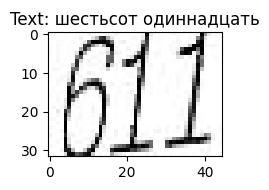

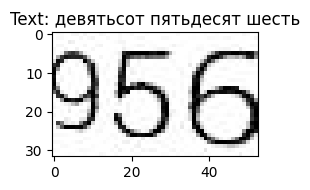

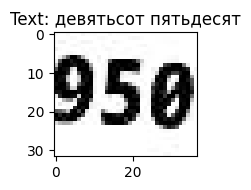

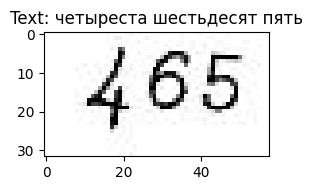

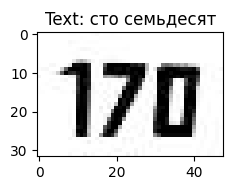

In [142]:
df = pd.read_csv('test.csv')
sample = df.sample(5)

display.display(sample)

for i in range(len(sample)):
    line = sample.iloc[i]
    image = imageio.imread('images/' + line['image'])
    text = line['text']

    plt.figure(figsize=(5, 2))
    plt.title(f'Text: {text}')
    plt.tight_layout()
    plt.imshow(image, cmap='Greys', vmin=0, vmax=255)
    plt.show()
    

In [143]:
ALPHABET = list('абвгдежзийклмнопрстуфхцчшщъыьэюя ')
# Максимальная генерируемая длина выхода
MAX_TARGET_SIZE = 33 # 2^N + 1, догадайтесь, кстати, почему +1
BATCH_SIZE = 1024
NUM_WORKERS = 4
HIDDEN_SIZE = 64

class SimpleCaptioningDataset(torch.utils.data.Dataset):
    def __init__(self, csv_path: str | Path, alphabet: tp.List[str], max_target_size: int, valid: bool = False) -> None:
        super().__init__()
        
        if isinstance(csv_path, str):
            csv_path = Path(csv_path)

        self._csv_path = csv_path
        self._alphabet = ['<pad>', '<bos>', '<eos>', '<unk>'] + alphabet
        self._max_target_size = max_target_size
        
        self._bos = '<bos>'
        self._bos_id = 1
        self._eos = '<eos>'
        self._eos_id = 2
        self._pad = '<pad>'
        self._pad_id = 0
        self._unk = '<unk>'
        self._unk_id = 3

        self._tok_to_id = {item: index for index, item in enumerate(self._alphabet)}

        
        self._markup = pd.read_csv(self._csv_path)
        self._markup_folder = self._csv_path.parent

        # Высота всех картинок в датасете - 32px, ширина - произвольная.
        # Здесь реализовано приведение к фиксированной ширине, вам же нужно будет в дополнительной части 
        # перепроектировать для работы в режиме navit
        self._augmentations = [] if valid else [
            A.ElasticTransform(p=0.2),
            A.GridDistortion(p=0.2),
            A.Perspective(p=0.2),
            A.RandomBrightnessContrast(p=0.3),
            A.RandomGamma(p=0.3),
            A.Affine(p=0.3),
        ]
        self._preprocessor = A.Compose(
            self._augmentations + 
            [
                A.Resize(
                    height=32,
                    width=256,
                ),
                A.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.0, p=1.0
                ),
                A.pytorch.ToTensorV2(),
            ]
        )

    def __len__(self) -> int:
        return len(self._markup)

    def _prepare_text(self, text: str) -> torch.Tensor:
        text = [self._bos] + list(text) + [self._eos]
        text = text[:self._max_target_size]
        text += [self._pad] * (self._max_target_size - len(text))
        token_ids = torch.Tensor([self._tok_to_id.get(tok, self._unk_id) for tok in text]).type(torch.int64)
        return token_ids

    def _text_with_shift(self, token_ids: torch.Tensor) -> tp.Tuple[torch.Tensor, torch.Tensor]:
        return token_ids[:-1], token_ids[1:]
    

    def __getitem__(self, index: int) -> tp.Tuple[tp.Tuple[torch.Tensor, torch.Tensor], torch.Tensor]:
        item = self._markup.iloc[index]
        image = cv2.imread(self._markup_folder / 'images' / item['image'], cv2.IMREAD_COLOR_RGB)
        image = self._preprocessor(image=image)['image']

        text = self._prepare_text(item['text'])

        text_in, text_out = self._text_with_shift(text)

        return (image, text_in), text_out
        

        

ds_train = SimpleCaptioningDataset(csv_path='train.csv', alphabet=ALPHABET, max_target_size=MAX_TARGET_SIZE)
ds_test = SimpleCaptioningDataset(csv_path='test.csv', alphabet=ALPHABET, max_target_size=MAX_TARGET_SIZE, valid=True)

loader_train = torch.utils.data.DataLoader(ds_train, batch_size=BATCH_SIZE, pin_memory=True, prefetch_factor=2, num_workers=NUM_WORKERS, shuffle=True, drop_last=True)
loader_test = torch.utils.data.DataLoader(ds_test, batch_size=BATCH_SIZE, pin_memory=True, prefetch_factor=2, num_workers=NUM_WORKERS, shuffle=True, drop_last=True)


In [144]:
class RotaryEmbedding(nn.Module):
    def __init__(self, d: int, max_wavelength: float = MAX_TARGET_SIZE * 4):
        super().__init__()
        inv_freq = 1.0 / (max_wavelength ** (torch.arange(0, d, 2).float() / d))
        self.register_buffer("inv_freq", inv_freq)

    def forward(
        self, 
        x: torch.Tensor, 
        start_index: tp.Union[int, torch.Tensor] = 0
    ) -> torch.Tensor:
        # x: (bs, seq_len, d)
        bs, seq_len, d = x.shape
        device = x.device
        
        if isinstance(start_index, int):
            pos = torch.arange(seq_len, device=device).unsqueeze(0) + start_index
        else:
            start_index = start_index.to(device).view(bs, 1)
            pos = torch.arange(seq_len, device=device).unsqueeze(0) + start_index
        
        # 2. Считаем углы freqs: (bs, seq_len, d//2)
        # einsum перемножает pos (bs, seq_len) и inv_freq (d//2)
        freqs = torch.einsum("bs,f->bsf", pos.float(), self.inv_freq)
        emb = torch.repeat_interleave(freqs, 2, dim=-1)
        cos, sin = emb.cos(), emb.sin()

        # 4. Поворачиваем x (interleaved: меняем местами соседние элементы и инвертируем знак четных)
        # Пример: [x0, x1, x2, x3] -> [-x1, x0, -x3, x2]
        x_rotated = torch.stack([-x[..., 1::2], x[..., 0::2]], dim=-1).reshape(bs, seq_len, d)

        # 5. Применяем RoPE
        return (x * cos) + (x_rotated * sin)


class VisionModel(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self._backbone = torchvision.models.mobilenet_v3_small(weights='IMAGENET1K_V1')
        self._channels_downsampler = nn.Conv2d(kernel_size=(1, 1), in_channels=576, out_channels=HIDDEN_SIZE)

        self._single_encoder_layer = nn.TransformerEncoderLayer(d_model=HIDDEN_SIZE, nhead=4, dropout=0.1, batch_first=True)
        self._transformer_encoder = nn.TransformerEncoder(self._single_encoder_layer, num_layers=3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: bs, 3, h, w
        x = self._backbone.features(x)
        # x: bs, 576, h // 32, w // 32
        x = self._channels_downsampler(x)
        # x: bs, 128, h // 32, w // 32
        x = x.reshape(-1, x.shape[1], x.shape[2] * x.shape[3]).permute(0, 2, 1)
        # x: bs, h // 32 * w // 32, 128
        # h // 32 * w // 32 = 8 по дефолту, каждая картинка = 8 токенов, всегда
        x = self._transformer_encoder(x)
        # x: bs, h // 32 * w // 32, 128
        return x


class GenerativeModel(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self._single_decoder_layer = nn.TransformerDecoderLayer(d_model=HIDDEN_SIZE, nhead=4, dropout=0.1, batch_first=True)
        self._transformer_decoder = nn.TransformerDecoder(self._single_decoder_layer, num_layers=3)

    def forward(self, seq: torch.Tensor, memory: torch.Tensor) -> torch.Tensor:
        tgt_mask = torch.nn.Transformer.generate_square_subsequent_mask(device=seq.device, sz=seq.shape[1])
        return self._transformer_decoder(tgt=seq, memory=memory, tgt_mask=tgt_mask[None, :, :], tgt_is_causal=True)


class CaptioningModel(nn.Module):
    def __init__(self, n_classes: int) -> None:
        super().__init__()
        
        self._n_classes = n_classes
        self._vision_model = VisionModel()
        self._generative_model = GenerativeModel()

        self._rotary = RotaryEmbedding(d=HIDDEN_SIZE)
        
        self._embeddings = nn.Embedding(num_embeddings=n_classes, embedding_dim=HIDDEN_SIZE // 4)
        self._in_linear = nn.Linear(in_features=HIDDEN_SIZE // 4, out_features=HIDDEN_SIZE)
        self._out_linear = nn.Linear(in_features=HIDDEN_SIZE, out_features=self._n_classes)

    def forward(self, seq: torch.Tensor, image: torch.Tensor, start_index: tp.Union[int, torch.Tensor] = 0) -> torch.Tensor:
        image_embeds = self._vision_model(image)
        image_embeds = self._rotary(image_embeds, start_index=0)
        
        seq = self._embeddings(seq)
        seq = self._in_linear(seq)
        seq = self._rotary(seq, start_index=start_index)
        
        seq = self._generative_model(seq, memory=image_embeds)
        seq = self._out_linear(seq)
        
        return seq

vision_model = VisionModel()
print(vision_model(torch.randn(1, 3, 32, 256)).shape)

generative_model = GenerativeModel()
print(generative_model(torch.randn(3, 2, HIDDEN_SIZE), torch.randn(3, 7, HIDDEN_SIZE)).shape)

captioning_model = CaptioningModel(n_classes=len(ALPHABET) + 8)
print(captioning_model(torch.zeros(3, 2, dtype=torch.long), torch.randn(3, 3, 32, 256)).shape)

torch.Size([1, 8, 64])
torch.Size([3, 2, 64])
torch.Size([3, 2, 41])


In [145]:
checkpoints_path = Path('checkpoints')
checkpoints_path.mkdir(exist_ok=True, parents=True)

In [146]:
class MaskedCrossEntropyLoss(nn.Module):
    def __init__(self, **kwargs: tp.Any) -> None:
        super().__init__()
        self._internal = nn.CrossEntropyLoss(**kwargs)

    def forward(self, pred: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
        loss_values = self._internal(pred.permute(0, 2, 1), tgt)
        loss_mask = torch.where(tgt > 0, torch.ones_like(tgt), torch.zeros_like(tgt)).type(loss_values.dtype)
        loss_values *= loss_mask 
        loss_value = loss_values.sum() / (loss_mask.sum() + 1e-4)
        return loss_value

# Train loop

---

## Задание 1: Валидация и метрики (2 балла)

### Что нужно сделать

Дополните цикл обучения и дообучите модель (нужно типа 30 эпох и лосс как минимум около 0.75):

1. **Добавьте валидацию:** После каждой эпохи обучения запустите проход по `loader_test` без градиентов
2. **Подсчитайте loss на валидации:** Используйте тот же `MaskedCrossEntropyLoss`
3. **Реализуйте метрики:**
   - **CER (Character Error Rate)** — процент ошибочных символов
   - **Exact Accuracy** — процент полностью правильных предсказаний

### Метрики: теория

#### Character Error Rate (CER)

CER измеряет **долю ошибок** на уровне символов, используя **расстояние Левенштейна** (edit distance):

$$
\text{CER} = \frac{\text{Insertions} + \text{Deletions} + \text{Substitutions}}{\text{Length of reference}} \times 100\%
$$

---

**Пример:**

* Reference: "двести сорок два"
* Hypothesis: "двесте сорак два"

---

* Total errors: 2
* Reference length: 17

CER = 2/17 ≈ 11.8%


#### Exact Match Accuracy

Exact Accuracy — **строгая метрика**: предсказание считается правильным **только** если полностью совпадает с ground truth:

$$
\text{Exact Acc} = \frac{\text{Number of exact matches}}{\text{Total samples}} \times 100\%
$$

---

**Пример:**

* Reference: "двести сорок два"
* Hypothesis: "двести сорок два" ✓ Exact match (Exact Acc += 1)

---

* Reference: "триста пять"
* Hypothesis: "триста пят" ✗ Not exact match (CER = 20%, но Exact Acc += 0)

### Что логировать

Выводите после каждой эпохи:
```
Epoch 001 | train_loss: 2.1234 | val_loss: 2.4567 | val_cer: 15.23% | val_exact_acc: 42.50%
```


In [147]:
torch.cuda.empty_cache()

loss = MaskedCrossEntropyLoss(label_smoothing=0.1, ignore_index=0, reduction='none') # ignore_index = index of '<pad>'!!!!
model = CaptioningModel(n_classes=len(ALPHABET) + 8)
model.to(device)

@torch.compile
def train_step(model, optimizer, loss, data) -> tp.Dict[str, torch.Tensor]:
    (image, src), tgt = data
    image = image.to(device)
    src = src.to(device)
    tgt = tgt.to(device)

    optimizer.zero_grad()
    
    pred = model(src, image)
    loss_value = loss(pred, tgt)
    loss_value.backward()

    optimizer.step()

    return {
        'loss': loss_value.item()
    }


In [ ]:
NUM_EPOCHS = 10

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.2)

for epoch in range(NUM_EPOCHS):
    metrics = defaultdict(list)
    for data in loader_train:
        optimizer.zero_grad()
        
        step_values = train_step(model, optimizer, loss, data)

        for k, v in step_values.items():
            metrics[k].append(v)

    log = f'Epoch: {epoch:3d}, '
    for k, v in metrics.items():
        avg = sum(v) / len(v)
        log += f'{k}: {avg:.04f}, '
        
    print(log)

    scheduler.step()
        
    torch.save(model.state_dict(), checkpoints_path / 'last.pth')


## Задание 2: Простой inference (2 балла)

### Что нужно сделать

Реализуйте функцию `run_inference_simple`, которая:

**Вход:** 
- `model` — обученная модель `CaptioningModel`
- `images` — батч изображений `torch.Tensor` размера `[batch_size, 3, 32, 256]` (уже нормализованные)

**Выход:**
- `List[str]` — список строк-описаний для каждого изображения, начинающихся с `<bos>` и заканчивающихся на `<eos>`

**Пример:**
```python
images = torch.randn(4, 3, 32, 256).to(device)
captions = run_inference_simple(model, images)

# captions = [
#     "<bos>двести сорок два<eos>",
#     "<bos>сто одиннадцать<eos>",
#     "<bos>триста пятьдесят<eos>",
#     "<bos>семьдесят семь<eos>"
# ]

```

1. **Энкодинг изображений:**
   ```python
   image_embeds = model.vision_model(images)  # [batch, seq_len, hidden_dim]
   image_embeds = model.rotary(image_embeds, start_index=0)
   ```

2. **Инициализация:** Начинаем с токена `<bos>` (id=1):
   ```python
   seq = ...  # [batch, 1]
   ```

3. **Autoregressive цикл:** На каждом шаге:
   - Эмбеддинг текущей последовательности
   - Применяем RoPE
   - Пропускаем через decoder
   - Берем логиты последнего токена
   - Выбираем токен с максимальной вероятностью (`argmax`)
   - Добавляем его к последовательности

4. **Остановка:** Генерируем до `MAX_TARGET_SIZE` токенов

5. **Декодирование:** Преобразуем `token_ids` обратно в строки через `dataset._alphabet`


In [138]:
def run_inference_simple(model: CaptioningModel, images: torch.Tensor) -> tp.List[str]:
    """
    Простой autoregressive inference без оптимизаций
    
    Args:
        model: обученная модель CaptioningModel
        images: батч изображений [batch_size, 3, 32, 256] (уже нормализованные, как на выходе из датасета)
    
    Returns:
        captions: список строк-описаний для каждого изображения
                  Формат: "<bos>текст<eos>"
    """
    raise NotImplementedError("Задание 2: Реализуйте run_inference_simple")


for i in range(10):
    index = random.randint(0, len(ds_test))
    (image, _), _ = ds_train[index]


    result = run_inference_simple(model, image[None, :, :, :].to(device))

    plt.title(result)
    plt.imshow(image.cpu().detach().numpy().transpose(1, 2, 0))
    plt.show()




## Задание 3: Early stopping + torch.compile (1 балл)

### Что нужно сделать

Улучшите `run_inference_simple` двумя способами:

1. **Early stopping генерации:**
   - Останавливайте цикл, когда **все** элементы батча сгенерировали `<eos>` (id=2)
   - Избегайте бесполезных вычислений после завершения генерации

2. **Оберните в `torch.compile` и проверьте, что это еще лучше ускоряет инференс (лучше на большой батче брать среднее время по нескольким прогонам):** 
   - Декорируйте функцию inference через `@torch.compile`
   - Или примените явно: `run_inference_compiled = torch.compile(run_inference_simple)`

### Пример early stopping

```python
# Трекаем, какие элементы батча уже закончили генерацию
finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

for step in range(max_length):
    # ... генерация нового токена ...
    
    # Проверяем, кто сгенерировал <eos>
    finished |= (next_token == eos_id)
    
    # Если все закончили - выходим
    if finished.all():
        break
```


## Задание 4: Inference с KV-cache (4 балла)

### Что нужно сделать

Реализуйте **оптимизированный inference** с использованием **KV-cache**:

Функция `run_inference_kv_cache` должна иметь **тот же интерфейс**, что и `run_inference_simple`, но работать **значительно быстрее** (для длинных последовательностей выходов, от 50 токенов).

### Теория: Что такое KV-cache?

#### Проблема наивного autoregressive inference

На каждом шаге генерации мы **пересчитываем** attention для **всей** предыдущей последовательности:

```python
Step 1: seq = [<bos>]              → compute attention(1 token)
Step 2: seq = [<bos>, "д"]         → compute attention(2 tokens)
Step 3: seq = [<bos>, "д", "в"]    → compute attention(3 tokens)
...
Step N: seq = [<bos>, ..., "а"]    → compute attention(N tokens)
```

**Избыточность:** Key и Value для токенов `[<bos>, "д", "в", ...]` **не меняются** между шагами!

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

На шаге $t$:
- $Q_t$ — query только для **нового** токена
- $K_{1:t-1}, V_{1:t-1}$ — keys/values предыдущих токенов (уже вычислены!)

#### Решение: KV-cache

**Идея:** Кэшируем $(K, V)$ для всех предыдущих токенов и **переиспользуем** их:

```python
# Step 1
K_cache = [K_1], V_cache = [V_1]
output_1 = Attention(Q_1, K_cache, V_cache)

# Step 2
K_cache = [K_1, K_2], V_cache = [V_1, V_2]  # Переиспользуем K_1, V_1!
output_2 = Attention(Q_2, K_cache, V_cache)

# Step 3
K_cache = [K_1, K_2, K_3], V_cache = [V_1, V_2, V_3]
output_3 = Attention(Q_3, K_cache, V_cache)
```

**Ускорение:**
- Без cache: $O(N \cdot L^2)$ где $L$ — длина генерации
- С cache: $O(N \cdot L)$

**На практике:** 2x–5x speedup для длинных последовательностей

### Как реализовать KV-cache в PyTorch

#### Шаг 1: Модифицируйте Transformer Decoder

Добавьте параметр `past_key_values` в forward:

```python
class GenerativeModel(nn.Module):
    def forward(self, seq, memory, past_key_values=None):
        # Если past_key_values передан, используем incremental decoding
        ...
```

**Проблема:** `nn.TransformerDecoder` из PyTorch **не поддерживает** KV-cache из коробки!

**Решение:**

1. **Простое (для этого ДЗ):** Используйте `torch.nn.functional.scaled_dot_product_attention` напрямую и ручное управление кэшем
2. **Production:** Используйте библиотеку `transformers` от HuggingFace (их модели поддерживают `past_key_values`)

Отнаследуйтесь от nn.TransformerDecoder и измените функцию forward

```python
def forward(self, seq: torch.Tensor, memory: torch.Tensor, past_kv_cache: torch.Tensor | None = None):
    """
    Args:
        seq: [batch, 1, hidden] - только НОВЫЙ токен
        memory: [batch, image_seq_len, hidden] - image embeddings
        past_kv_cache: List[Tuple[K, V]] для каждого decoder layer
    
    Returns:
        output: [batch, 1, hidden]
        new_kv_cache: обновленный cache
    """
    # Todo
    
    return x, new_kv_cache
```

In [ ]:
def run_inference_kv_cache(model: CaptioningModel, images: torch.Tensor) -> tp.List[str]:
    """
    Оптимизированный autoregressive inference с KV-cache
    
    Args:
        model: обученная модель CaptioningModel
        images: батч изображений [batch_size, 3, 32, 256]
    
    Returns:
        captions: список строк-описаний (тот же формат, что и ранее)
    """
    # TODO: Implement KV-cache optimization
    # Hint 1: Forward проходит только ПОСЛЕДНИЙ токен, а не вся последовательность
    # Hint 2: Кэшируйте (K, V) из предыдущих шагов
    # Hint 3: past_key_values растет на каждом шаге: [batch, step, hidden]
    # Hint 4: Ваша реализация должна быть минимум в 1.5x быстрее run_inference_simple 
    #    (на время декодирования без времени подсчета эмбеддингов изображения)
    
    raise NotImplementedError("Задание 4: Реализуйте run_inference_kv_cache")

for i in range(10):
    index = random.randint(0, len(ds_test))
    (image, _), _ = ds_train[index]


    result = run_inference_kv_cache(model, image[None, :, :, :].to(device))

    plt.title(result)
    plt.imshow(image.cpu().detach().numpy().transpose(1, 2, 0))
    plt.show()